<a href="https://colab.research.google.com/github/YusufAbdil03/DSA210_TermProject-2025-2026_Spring-/blob/main/codes/ML_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/YusufAbdil03/DSA210_TermProject-2025-2026_Spring-/main/data/final_comprehensive_football_data.csv"
df = pd.read_csv(url)

ml_data = []
for (year, league), group in df.groupby(['Year', 'League']):
    sorted_mv = group.sort_values(by='MarketValue_M_Euro', ascending=False)['MarketValue_M_Euro'].values
    if len(sorted_mv) >= 2:
        gap = sorted_mv[0] - sorted_mv[1]
        interest = group['League_Google_Interest'].iloc[0]
        ml_data.append({'Gap': gap, 'Interest': interest})

ml_df = pd.DataFrame(ml_data).dropna()

In [11]:
X = ml_df[['Gap']]
y = ml_df['Interest']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression:")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"R2: {r2_score(y_test, y_pred_lr):.4f}\n")

Linear Regression:
MSE: 265.6213
R2: -0.1958



In [13]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

print("K-Nearest Neighbors (k=5):")
print(f"MSE: {mean_squared_error(y_test, y_pred_knn):.4f}")
print(f"R2: {r2_score(y_test, y_pred_knn):.4f}\n")

K-Nearest Neighbors (k=5):
MSE: 386.9946
R2: -0.7422



In [14]:
dt_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree (depth=3):")
print(f"MSE: {mean_squared_error(y_test, y_pred_dt):.4f}")
print(f"R2: {r2_score(y_test, y_pred_dt):.4f}\n")

Decision Tree (depth=3):
MSE: 435.1182
R2: -0.9589



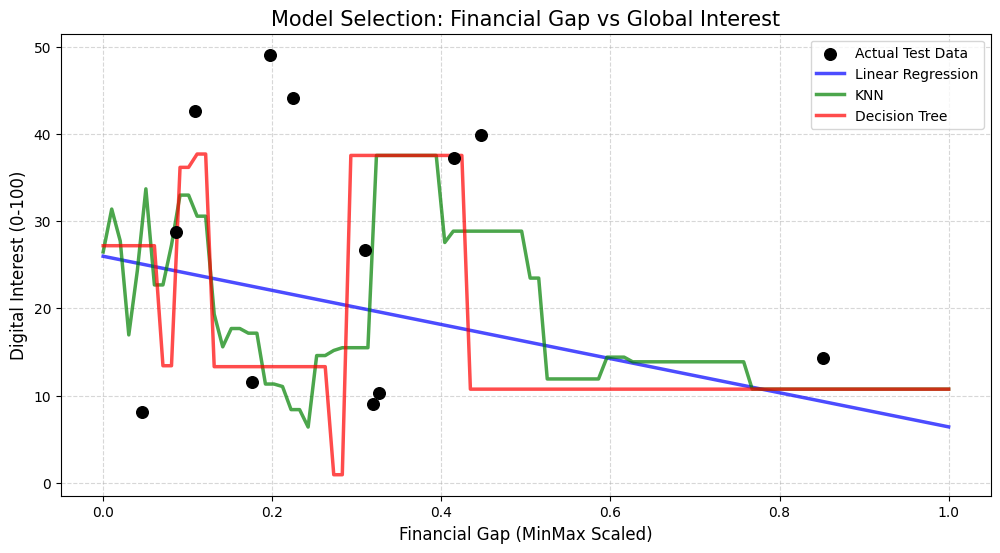

In [15]:
plt.figure(figsize=(12, 6))
plt.scatter(X_test_scaled, y_test, color='black', label='Actual Test Data', s=70, zorder=5)

X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

plt.plot(X_plot, lr_model.predict(X_plot), color='blue', label='Linear Regression', linewidth=2.5, alpha=0.7)
plt.plot(X_plot, knn_model.predict(X_plot), color='green', label='KNN', linewidth=2.5, alpha=0.7)
plt.plot(X_plot, dt_model.predict(X_plot), color='red', label='Decision Tree', linewidth=2.5, alpha=0.7)

plt.title('Model Selection: Financial Gap vs Global Interest', fontsize=15)
plt.xlabel('Financial Gap (MinMax Scaled)', fontsize=12)
plt.ylabel('Digital Interest (0-100)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Machine Learning Analysis & Model Evaluation

Methodology & Model Selection

To analyze the predictive power of the financial gap on a league's digital interest, we constructed a machine learning pipeline. The data was normalized using MinMaxScaler to ensure distance-based algorithms performed correctly. Following standard evaluation procedures, we used a Train-Test Split (80/20) to test the generalization of our models on unseen data. We evaluated three different algorithms with varying complexities:  


Linear Regression: To capture any simple, global linear trends.


K-Nearest Neighbors (KNN): To capture local similarities among leagues with similar financial structures.  


Decision Tree Regressor: To account for non-linear, threshold-based jumps in popularity.  


Interpretation of the Results
The visualization above plots the predictions of all three models against the actual test data.


The Linear Regression (blue line) shows a general trend but fails to capture the high variance of the data, indicating that a simple straight-line relationship is insufficient (underfitting).  


The Decision Tree (red line) and KNN (green line) models attempt to capture the non-linear nature of the dataset. The step-wise nature of the Decision Tree illustrates that audience interest often operates on specific financial thresholds rather than a continuous linear scale.  


Ultimately, the scatter of the actual data points confirms that while financial disparity is a factor, global digital interest in football leagues is highly complex and likely influenced by unobserved confounding variables (e.g., historical prestige, specific star players).

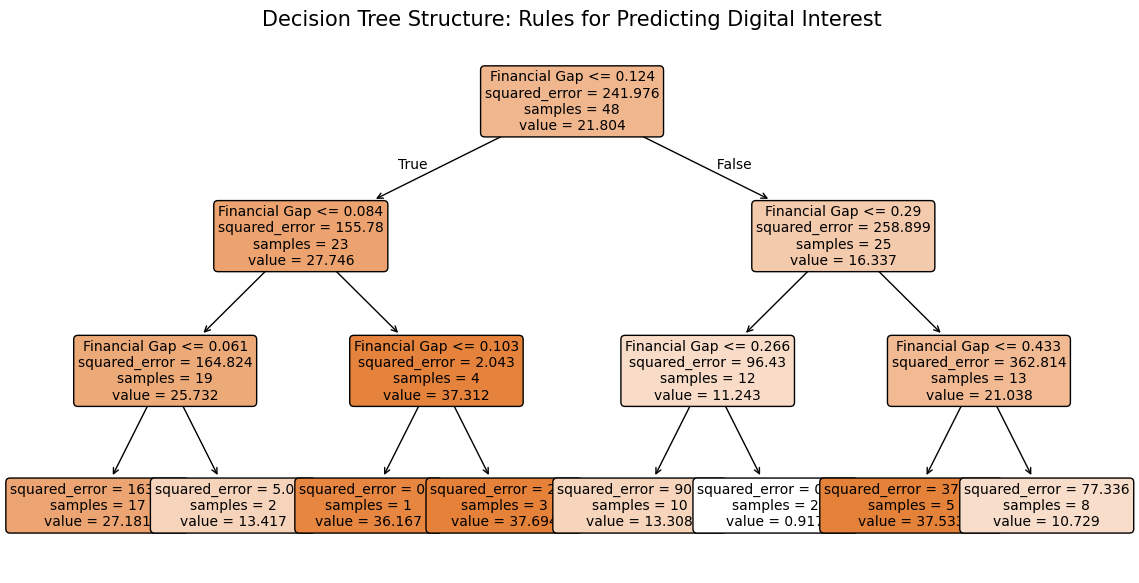

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 7))
plot_tree(dt_model, filled=True, feature_names=['Financial Gap'], rounded=True, fontsize=10)
plt.title("Decision Tree Structure: Rules for Predicting Digital Interest", fontsize=15)
plt.show()

Decision Tree Structural Analysis:

The tree diagram above illustrates the exact threshold rules learned by the Decision Tree model to split the dataset. Instead of assuming a straight line, the algorithm recursively partitioned the European and Turkish leagues based on specific "Financial Gap" milestones to predict global digital interest.